<a href="https://colab.research.google.com/github/KunderLavanya/APS_LAB/blob/main/aps3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression



In [3]:
#load the dataset
data=load_breast_cancer()
x=pd.DataFrame(data.data,
               columns=data.feature_names
               )
y=pd.Series(
    (data.target==0).astype(int),
name="malignant"
)
print(y.value_counts())
print("Feature matrix shape:", x.shape)
print("Target shape",y.shape)
print("Class name:", data.target_names)


malignant
0    357
1    212
Name: count, dtype: int64
Feature matrix shape: (569, 30)
Target shape (569,)
Class name: ['malignant' 'benign']


In [4]:
class_counts=y.value_counts().sort_index()
class_distribution=pd.DataFrame({
    "class":data.target_names,
    "Count": class_counts.values,
    "probability": class_counts.values/len(y)
    })
print(class_distribution)

       class  Count  probability
0  malignant    357     0.627417
1     benign    212     0.372583


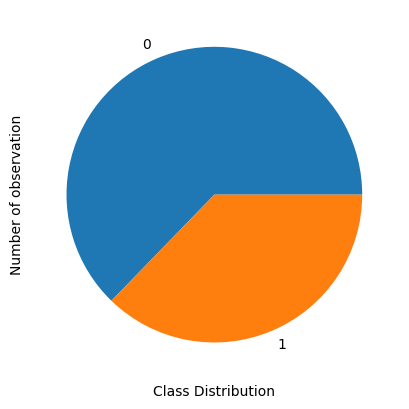

In [5]:
class_distribution.plot(
    x="class",
    y="Count",kind="pie",
    legend=False,
    color=["orange","blue"]
)
plt.ylabel("Number of observation")
plt.xlabel("Class Distribution")
plt.xticks(rotation=0)
plt.show()

In [6]:
x_train,x_test, y_train, y_test=train_test_split(
    x,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Training size:", len(y_train))
print("testing size: ", len(y_test))
print("training propotions")
print(y_train.value_counts(normalize=True).sort_index())
print("testing propotions")
print(y_test.value_counts(normalize=True).sort_index())


Training size: 455
testing size:  114
training propotions
malignant
0    0.626374
1    0.373626
Name: proportion, dtype: float64
testing propotions
malignant
0    0.631579
1    0.368421
Name: proportion, dtype: float64


In [7]:
model=make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)
model.fit(x_train,y_train)
# y_pred=model.predict(x_test)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(max_iter=1000))])

In [8]:
probabalities=model.predict_proba(x_test)
print(probabalities[:5])

[[9.99635432e-01 3.64568116e-04]
 [1.07465986e-08 9.99999989e-01]
 [9.57432053e-01 4.25679471e-02]
 [4.23812678e-01 5.76187322e-01]
 [4.90844511e-01 5.09155489e-01]]


In [9]:
print(probabalities[:5].sum(axis=1))

[1. 1. 1. 1. 1.]


In [10]:
results=pd.DataFrame({
    "Actual_class":y_test.values,
    "P_malignant":probabalities[:,0],
    "P_benign":probabalities[:,1]
})
print(results.head(10))


   Actual_class   P_malignant  P_benign
0             0  9.996354e-01  0.000365
1             1  1.074660e-08  1.000000
2             0  9.574321e-01  0.042568
3             1  4.238127e-01  0.576187
4             0  4.908445e-01  0.509155
5             0  9.993840e-01  0.000616
6             1  2.384659e-01  0.761534
7             0  9.989878e-01  0.001012
8             0  9.994313e-01  0.000569
9             0  9.892324e-01  0.010768


In [13]:
results["Actual_label"]=results["Actual_class"].map({
    0:"malignant",
    1:"Benign"
})
print(results[ ['Actual_label',"P_malignant","P_benign"]].head(10))

  Actual_label   P_malignant  P_benign
0    malignant  9.996354e-01  0.000365
1       Benign  1.074660e-08  1.000000
2    malignant  9.574321e-01  0.042568
3       Benign  4.238127e-01  0.576187
4    malignant  4.908445e-01  0.509155
5    malignant  9.993840e-01  0.000616
6       Benign  2.384659e-01  0.761534
7    malignant  9.989878e-01  0.001012
8    malignant  9.994313e-01  0.000569
9    malignant  9.892324e-01  0.010768


In [18]:
threshold=0.50
results["Predicted_malignant"]=(
    results["P_malignant"]>=threshold
).astype(int)
results["Predicted_label"]=results["Predicted_malignant"].map({
    1:"malignant",
    0:"Benign"
}
)
print(results[
    ["Actual_label","P_malignant","Predicted_label"]
].head(10))

  Actual_label   P_malignant Predicted_label
0    malignant  9.996354e-01       malignant
1       Benign  1.074660e-08          Benign
2    malignant  9.574321e-01       malignant
3       Benign  4.238127e-01          Benign
4    malignant  4.908445e-01          Benign
5    malignant  9.993840e-01       malignant
6       Benign  2.384659e-01          Benign
7    malignant  9.989878e-01       malignant
8    malignant  9.994313e-01       malignant
9    malignant  9.892324e-01       malignant


In [17]:
for threshold in [0.30,0.50,0.70]:
  predictions=(
      results["P_malignant"]>=threshold).astype(int)
  print(
      f"threshold={threshold}:"
      f"Predicted malignant cases = {predictions.sum()}"
  )


threshold=0.3:Predicted malignant cases = 76
threshold=0.5:Predicted malignant cases = 74
threshold=0.7:Predicted malignant cases = 72


In [21]:
from sklearn.metrics import confusion_matrix
actual_malignant=(y_test.values==0).astype(int)
for threshold in [0.30,0.50,0.70]:
  predicted_malignant=(
      probabalities[:,0]>=threshold).astype(int)
  cm=confusion_matrix(actual_malignant,predicted_malignant)
  print(f"\n Threshold={threshold}")
  print(cm)


 Threshold=0.3
[[38  4]
 [ 0 72]]

 Threshold=0.5
[[39  3]
 [ 1 71]]

 Threshold=0.7
[[41  1]
 [ 1 71]]
